In [ ]:
# ## Dataset Overview
# - Approximately 1300 web-scraped images of skin burns
# - YOLO format labels (0=1st degree, 1=2nd degree, 2=3rd degree)
# - Mixed file types (.jpg, .jpeg, .txt annotations)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import random

#Visualization Settings
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')
plt.rcParams['image.cmap'] = 'viridis'

In [8]:
# ## Dataset Structure Analysis
dataset_path = 'kaggle-thermal-burn-dataset/'
class_names = {
    0: '1st_degree',
    1: '2nd_degree',
    2: '3rd_degree'
}

# Analyze file distribution
image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.jpeg'))]
label_files = [f for f in os.listdir(dataset_path) if f.endswith('.txt')]

print(f"Total images: {len(image_files)}")
print(f"Total labels: {len(label_files)}")
print(f"Missing images: {len(label_files) - len(image_files)}")
print(f"Missing labels: {len(image_files) - len(label_files)}")

Total images: 1227
Total labels: 1441
Missing images: 214
Missing labels: -214


In [ ]:
# ## Class Distribution Analysis

# Parse YOLO labels to get class distribution
class_counts = {0: 0, 1: 0, 2: 0}

for label_file in label_files[:1000]:
    try:
        with open(os.path.join(dataset_path, label_file), 'r') as f:
            for line in f:
                class_id = int(line.strip().split()[0])
                if class_id in class_counts:
                    class_counts[class_id] += 1
    except Exception as e:
        print(f"Error processing {label_file}: {e}")


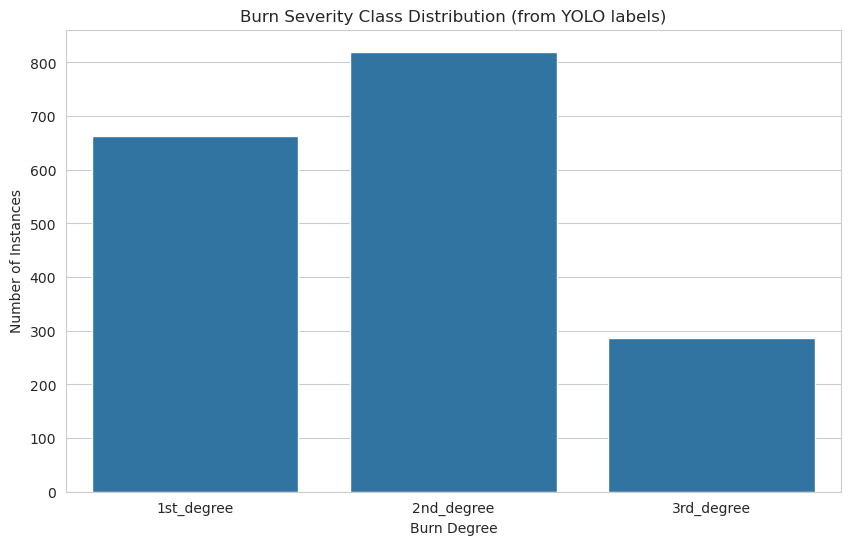

In [10]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=[class_names[k] for k in class_counts.keys()],
            y=list(class_counts.values()))
plt.title('Burn Severity Class Distribution (from YOLO labels)')
plt.xlabel('Burn Degree')
plt.ylabel('Number of Instances')
plt.show()

In [12]:
# ## Image Properties Analysis

def analyze_image_sample(sample_size=5):
    """Analyze a random sample of images"""
    sample_images = random.sample(image_files, min(sample_size, len(image_files)))
    properties = []

    for img_file in sample_images:
        try:
            img_path = os.path.join(dataset_path, img_file)
            with Image.open(img_path) as img:
                # Get corresponding label file
                label_file = img_file.rsplit('.', 1)[0] + '.txt'
                class_ids = []
                if os.path.exists(os.path.join(dataset_path, label_file)):
                    with open(os.path.join(dataset_path, label_file), 'r') as f:
                        for line in f:
                            class_ids.append(int(line.strip().split()[0]))

                properties.append({
                    'filename': img_file,
                    'classes': class_ids,
                    'format': img.format,
                    'mode': img.mode,
                    'size': img.size,
                    'width': img.width,
                    'height': img.height
                })
        except Exception as e:
            print(f"Error processing {img_file}: {e}")

    return pd.DataFrame(properties)

image_properties = analyze_image_sample(20)
print("\nImage Properties Summary:")
print(image_properties[['filename', 'classes', 'width', 'height', 'mode']].head())

print("\nStatistics:")
print(image_properties[['width', 'height']].describe())


Image Properties Summary:
      filename classes  width  height mode
0  img1138.jpg     [0]    303     166  RGB
1   img375.jpg     [2]    720     960  RGB
2   img918.jpg     [1]    297     170  RGB
3   img237.jpg     [1]    260     194  RGB
4    img18.jpg     [0]    275     183  RGB

Statistics:
            width      height
count   20.000000   20.000000
mean   334.250000  259.100000
std    167.330708  190.338175
min    180.000000  166.000000
25%    266.000000  169.500000
50%    278.500000  183.000000
75%    300.000000  234.750000
max    800.000000  960.000000


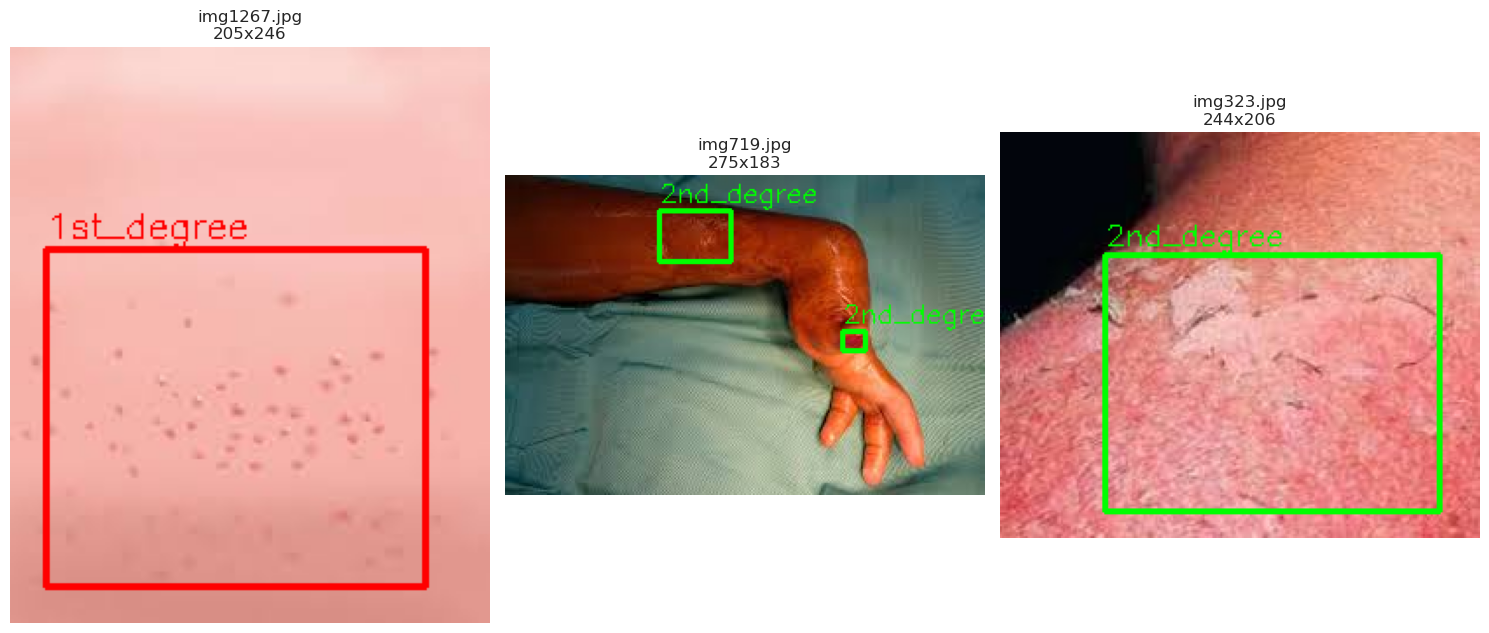

In [13]:
# ##  Visual Examination with Bounding Boxes

def plot_image_with_boxes(img_file, ax=None):
    """Plot image with YOLO bounding boxes"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    img_path = os.path.join(dataset_path, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get corresponding label file
    label_file = img_file.rsplit('.', 1)[0] + '.txt'
    if os.path.exists(os.path.join(dataset_path, label_file)):
        with open(os.path.join(dataset_path, label_file), 'r') as f:
            for line in f:
                class_id, x_center, y_center, width, height = map(float, line.strip().split())

                # Convert YOLO to pixel coordinates
                img_h, img_w = img.shape[:2]
                x_center *= img_w
                y_center *= img_h
                width *= img_w
                height *= img_h

                # Calculate rectangle coordinates
                x_min = int(x_center - width/2)
                y_min = int(y_center - height/2)
                x_max = int(x_center + width/2)
                y_max = int(y_center + height/2)

                # Draw rectangle
                color = [(255, 0, 0), (0, 255, 0), (0, 0, 255)][int(class_id)]
                cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 2)
                cv2.putText(img, class_names[int(class_id)],
                            (x_min, y_min-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{img_file}\n{img.shape[1]}x{img.shape[0]}")
    return ax

sample_images = random.sample(image_files, min(3, len(image_files)))

plt.figure(figsize=(15, 10))
for i, img_file in enumerate(sample_images, 1):
    ax = plt.subplot(1, 3, i)
    plot_image_with_boxes(img_file, ax)
plt.tight_layout()
plt.show()

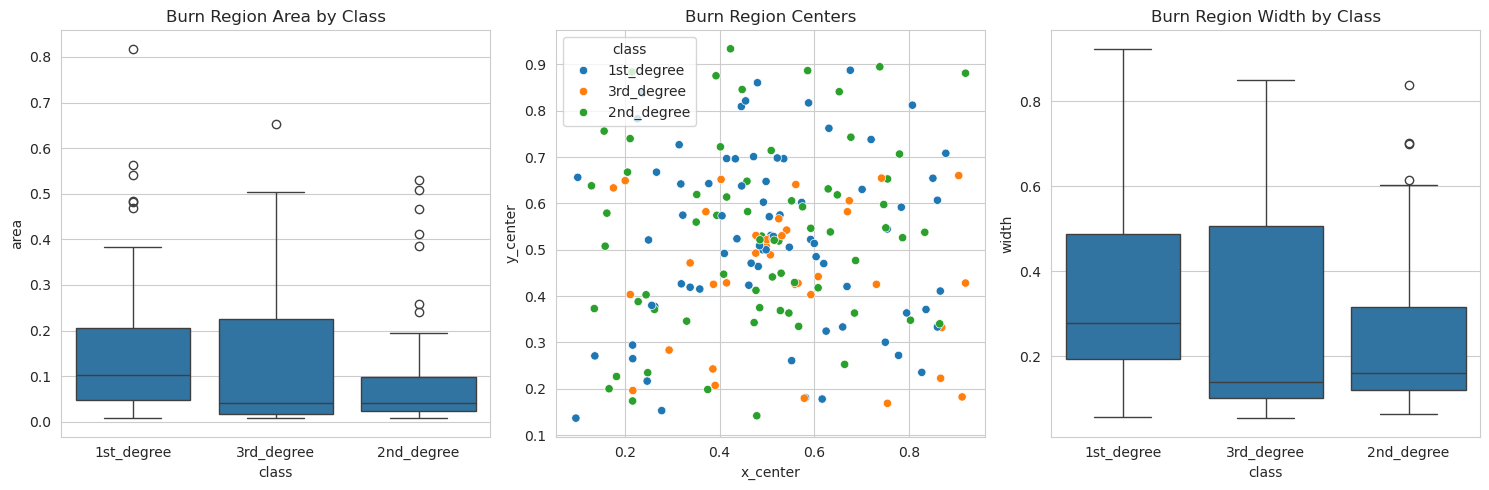

In [15]:
# ## Burn Region Analysis

def analyze_burn_regions(sample_size=5):
    """Analyze size and position of burn regions"""
    sample_labels = random.sample(label_files, min(sample_size, len(label_files)))
    burn_stats = []

    for label_file in sample_labels:
        try:
            with open(os.path.join(dataset_path, label_file), 'r') as f:
                for line in f:
                    class_id, x_center, y_center, width, height = map(float, line.strip().split())
                    burn_stats.append({
                        'class': class_names[int(class_id)],
                        'x_center': x_center,
                        'y_center': y_center,
                        'width': width,
                        'height': height,
                        'area': width * height
                    })
        except Exception as e:
            print(f"Error processing {label_file}: {e}")

    return pd.DataFrame(burn_stats)

burn_stats = analyze_burn_regions(100)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='class', y='area', data=burn_stats)
plt.title('Burn Region Area by Class')

plt.subplot(1, 3, 2)
sns.scatterplot(x='x_center', y='y_center', hue='class', data=burn_stats)
plt.title('Burn Region Centers')

plt.subplot(1, 3, 3)
sns.boxplot(x='class', y='width', data=burn_stats)
plt.title('Burn Region Width by Class')

plt.tight_layout()
plt.show()